# Offline Model Extraction: A Stolen Clone That Needs No Network

This notebook tells the story of **Lab 3**. A small neural-net victim classifies
8x8 handwritten digits behind an API that returns only a hard label (0-9). With
nothing but query access we steal a **Random Forest clone**, and then show the
real danger: the clone is a **standalone file** that runs with the network cut.

All attack logic is imported from `train_victim.py` and `extract.py` - this
notebook adds **no duplicate logic**, only exploration and visualization.

**Dataset:** scikit-learn `load_digits` (1,797 images, 10 balanced classes)
**Victim:** `StandardScaler` + `MLPClassifier(hidden_layer_sizes=(128,))`
**Clone:** `RandomForestClassifier` trained only on victim-labeled queries

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# The lab scripts live in the parent folder; add it to the path so we can
# IMPORT the victim and the attack logic instead of re-writing it.
LAB_DIR = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(LAB_DIR))

import train_victim as victim_mod   # load_data(), make_splits(), victim_predict()
import extract as atk               # the whole attack toolkit

print('Imports OK. Lab dir:', LAB_DIR)

Imports OK. Lab dir: c:\Users\Hasina Rindra\adversarial-ml\extraction\offline-model-extraction


## 1. The data and the disjoint three-way split

The 1,797 digits are carved into three slices that **never overlap**: the victim
trains on one, the attacker gets a second as an *unlabeled* query pool, and a
third is held out to score everyone honestly.

[INFO] Loading sklearn digits dataset (no download needed) ...
  1,797 images  |  64 features each (8x8 pixels)  |  10 balanced classes (0-9)

[INFO] Disjoint split  ->  victim-train: 497   attacker-pool: 1,000   test: 300
victim-train :   497  (the only data the victim learns from)
attacker-pool:  1000  (UNLABELED - attacker must query for labels)
held-out test:   300  (nobody trains on this)


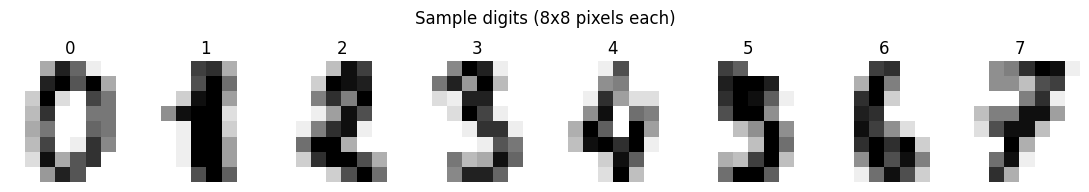

In [2]:
# Use the SAME loader and splitter the victim uses, so we see exactly what it sees.
X, y = victim_mod.load_data()
X_vtrain, y_vtrain, X_pool, X_test, y_test = victim_mod.make_splits(X, y)

print(f'victim-train : {len(X_vtrain):>5}  (the only data the victim learns from)')
print(f'attacker-pool: {len(X_pool):>5}  (UNLABELED - attacker must query for labels)')
print(f'held-out test: {len(X_test):>5}  (nobody trains on this)')

# Show a few raw digits so we know what the models are looking at.
fig, axes = plt.subplots(1, 8, figsize=(11, 2))
for ax, img, label in zip(axes, X[:8], y[:8]):
    ax.imshow(img.reshape(8, 8), cmap='gray_r')
    ax.set_title(f'{label}')
    ax.axis('off')
fig.suptitle('Sample digits (8x8 pixels each)')
plt.tight_layout(); plt.show()

## 2. The victim is a black box

The attacker may call only `victim_predict(X)` and read back a hard label - never
the weights, the code, or any probability. Let's confirm the victim is a strong
classifier on the held-out test set, using exactly that black-box channel.

In [3]:
# Query the victim through its black-box API (loads victim_mlp.pkl internally).
victim_test_preds = victim_mod.victim_predict(X_test)
victim_acc = (victim_test_preds == y_test).mean()
print(f'Victim accuracy on the test set: {victim_acc*100:.2f}%')
print('(We only ever saw labels - never the model behind them.)')

Victim accuracy on the test set: 96.00%
(We only ever saw labels - never the model behind them.)


## 3. Extraction: more queries -> a better clone

For a range of **query budgets** we draw that many unlabeled images, ask the
victim to label them, train a fresh Random Forest clone on the stolen
`(image, victim-label)` pairs, and measure **agreement** with the victim on the
test set.

Agreement = the fraction of test images where the clone predicts the *same* label
as the victim. It is the real measure of how well we cloned the model. The
attacker's pool holds 1,000 images, so that is the largest honest budget here.

  budget    50 done
  budget   100 done
  budget   200 done
  budget   350 done
  budget   500 done
  budget   750 done
  budget  1000 done


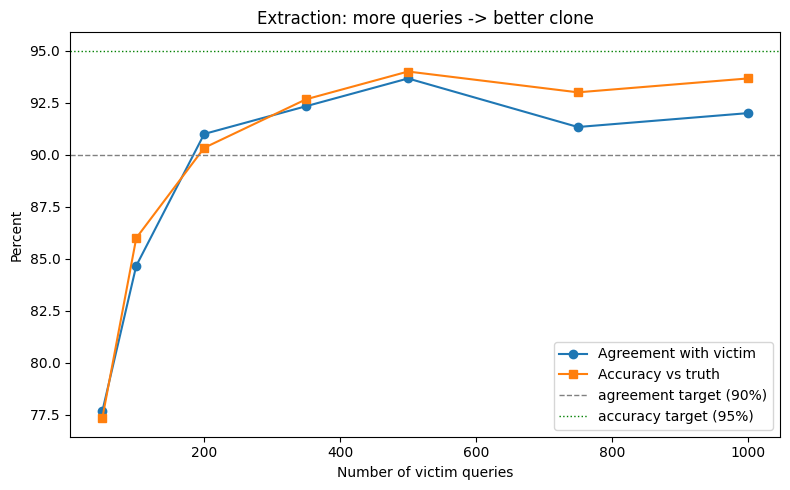

In [4]:
# Budgets up to the full pool size (1,000 = the attacker's entire stock).
budgets = [50, 100, 200, 350, 500, 750, 1000]
agree_curve, acc_curve = [], []

for n in budgets:
    # Steal n labels by querying the victim's black box (same seed -> reproducible).
    X_stolen, y_stolen = atk.build_stolen_dataset(victim_mod.victim_predict, X_pool, n)

    # Guard: a tiny budget could (in principle) miss a digit class entirely; a
    # single-class stolen set can't train a classifier, so we skip that budget.
    if len(np.unique(y_stolen)) < 2:
        agree_curve.append(None); acc_curve.append(None)
        print(f'  budget {n:>5} skipped (only one class in stolen labels)')
        continue

    clone = atk.get_clone()
    atk.train_clone(clone, X_stolen, y_stolen)
    clone_preds = clone.predict(X_test)
    agree_curve.append(atk.agreement_rate(victim_test_preds, clone_preds))
    acc_curve.append((clone_preds == y_test).mean())
    print(f'  budget {n:>5} done')

plt.figure(figsize=(8, 5))
pts = [(b, ag, ac) for b, ag, ac in zip(budgets, agree_curve, acc_curve) if ag is not None]
bs, ags, acs = zip(*pts)
plt.plot(bs, [a*100 for a in ags], marker='o', label='Agreement with victim')
plt.plot(bs, [a*100 for a in acs], marker='s', label='Accuracy vs truth')
plt.axhline(90, color='gray', ls='--', lw=1, label='agreement target (90%)')
plt.axhline(95, color='green', ls=':', lw=1, label='accuracy target (95%)')
plt.xlabel('Number of victim queries')
plt.ylabel('Percent')
plt.title('Extraction: more queries -> better clone')
plt.legend(); plt.tight_layout(); plt.show()

## 4. Victim vs clone, side by side on real digits

At the full 1,000-query budget, we line up test digits with the victim's label and
the clone's label. Where they disagree, the clone has not perfectly copied the
victim - but those cases are rare.

Clone agreement with victim : 92.00%
Clone accuracy vs truth     : 93.67%


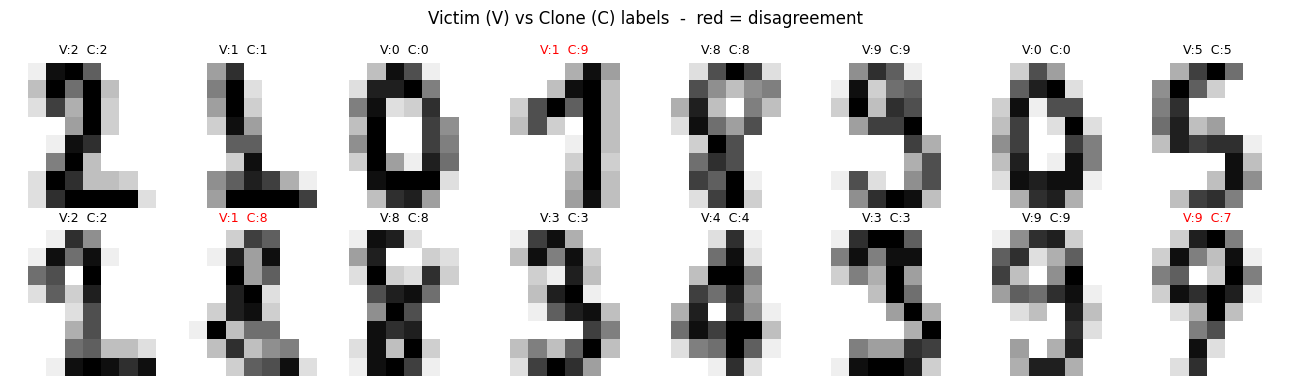

In [ ]:
# Full-budget clone for the side-by-side comparison.
X_stolen, y_stolen = atk.build_stolen_dataset(victim_mod.victim_predict, X_pool, atk.N_QUERIES)
clone = atk.get_clone()
atk.train_clone(clone, X_stolen, y_stolen)

clone_preds = clone.predict(X_test)
agree = atk.agreement_rate(victim_test_preds, clone_preds)
acc = (clone_preds == y_test).mean()
print(f'Clone agreement with victim : {agree*100:.2f}%')
print(f'Clone accuracy vs truth     : {acc*100:.2f}%')

# Show 16 test digits with both labels; red title = victim and clone disagree.
fig, axes = plt.subplots(2, 8, figsize=(13, 4))
for ax, img, vp, cp in zip(axes.ravel(), X_test[:16], victim_test_preds[:16], clone_preds[:16]):
    ax.imshow(img.reshape(8, 8), cmap='gray_r')
    color = 'black' if vp == cp else 'red'
    ax.set_title(f'V:{vp}  C:{cp}', color=color, fontsize=9)
    ax.axis('off')
fig.suptitle('Victim (V) vs Clone (C) labels  -  red = disagreement')
plt.tight_layout(); plt.show()

## 5. Key takeaway: the clone is a portable asset

Using only black-box, *hard-label* queries - no access to the victim's data,
weights, or code - we trained a Random Forest that reproduces the victim's
decisions on the large majority of test images, and even matches its raw accuracy.

**Why Lab 3 goes further than Lab 2:** the stolen clone is saved as a single
`clone_rf.pkl`. Run `python offline_inference.py` and it classifies digits with
the **network physically disabled** - if any line tried to reach the victim's API
or the internet, the script would crash. It doesn't, which proves the clone is
self-contained.

**Why that is the real threat:**
- **Rate limits, quotas, and anomaly detection all live at the API** - and a local
  clone bypasses every one of them.
- A local copy lets an attacker design **evasion attacks** (Lab 1) offline, with
  zero risk of detection, then fire them at the live system.
- Revoking an API key does nothing once the model already walked out the door in
  a `.pkl` file.